In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats


In [7]:
index_names = ['unit_number', 'time_cycles']
operational_settings = ['setting_1', 'setting_2', 'setting_3']

sensor_names = [f'S_{i}' for i in range(1,22)]
col_names = index_names + operational_settings + sensor_names

print(f"Column names defined. Total columns: {len(col_names)}")

Column names defined. Total columns: 26


In [8]:
train_df  = pd.read_csv(f'train_FD001.txt', sep=r'\s+', header=None, names=col_names)
test_df  = pd.read_csv(f'test_FD001.txt', sep=r'\s+', header=None, names=col_names)
rul_df  = pd.read_csv(f'RUL_FD001.txt', sep=r'\s+', header=None, names=col_names)

pd.set_option("display.max_columns", None)
train_df

,unit_number,time_cycles,setting_1,setting_2,setting_3,S_1,S_2,S_3,S_4,S_5,S_6,S_7,S_8,S_9,S_10,S_11,S_12,S_13,S_14,S_15,S_16,S_17,S_18,S_19,S_20,S_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,21.61,551.43,2388.19,9065.52,1.3,48.07,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,21.61,550.86,2388.23,9065.11,1.3,48.04,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,21.61,550.94,2388.24,9065.90,1.3,48.09,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,21.61,550.68,2388.25,9073.72,1.3,48.39,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640


In [9]:
train_df.isnull().sum()

,0
unit_number,0
time_cycles,0
setting_1,0
setting_2,0
setting_3,0
S_1,0
S_2,0
S_3,0
S_4,0
S_5,0


In [10]:
print(train_df.dtypes)

unit_number      int64
time_cycles      int64
setting_1      float64
setting_2      float64
setting_3      float64
S_1            float64
S_2            float64
S_3            float64
S_4            float64
S_5            float64
S_6            float64
S_7            float64
S_8            float64
S_9            float64
S_10           float64
S_11           float64
S_12           float64
S_13           float64
S_14           float64
S_15           float64
S_16           float64
S_17             int64
S_18             int64
S_19           float64
S_20           float64
S_21           float64
dtype: object


In [11]:
train_df.describe()

,unit_number,time_cycles,setting_1,setting_2,setting_3,S_1,S_2,S_3,S_4,S_5,S_6,S_7,S_8,S_9,S_10,S_11,S_12,S_13,S_14,S_15,S_16,S_17,S_18,S_19,S_20,S_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,2.063100e+04,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,5.186700e+02,642.680934,1590.523119,1408.933782,1.462000e+01,21.609803,553.367711,2388.096652,9065.242941,1.300000e+00,47.541168,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,6.537152e-11,0.500053,6.131150,9.000605,3.394700e-12,0.001389,0.885092,0.070985,22.082880,4.660829e-13,0.267087,0.737553,0.071919,19.076176,0.037505,1.556432e-14,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,5.186700e+02,641.210000,1571.040000,1382.250000,1.462000e+01,21.600000,549.850000,2387.900000,9021.730000,1.300000e+00,46.850000,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,5.186700e+02,642.325000,1586.260000,1402.360000,1.462000e+01,21.610000,552.810000,2388.050000,9053.100000,1.300000e+00,47.350000,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,5.186700e+02,642.640000,1590.100000,1408.040000,1.462000e+01,21.610000,553.440000,2388.090000,9060.660000,1.300000e+00,47.510000,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,5.186700e+02,643.000000,1594.380000,1414.555000,1.462000e+01,21.610000,554.010000,2388.140000,9069.420000,1.300000e+00,47.700000,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,5.186700e+02,644.530000,1616.910000,1441.490000,1.462000e+01,21.610000,556.060000,2388.560000,9244.590000,1.300000e+00,48.530000,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [12]:
train_df.groupby('unit_number')['time_cycles'].max()

,time_cycles
unit_number,
1,192
2,287
3,179
4,189
5,269
...,...
96,336
97,202
98,156


Il y a 100 moteur différents avec des temps de cylces varié. On en conclu qu'il n'y a pas une durée standard de vie pour les moteurs


# **choix des capteurs**

## **Etape 1**  : Exploration visuelle et ration pente/bruit

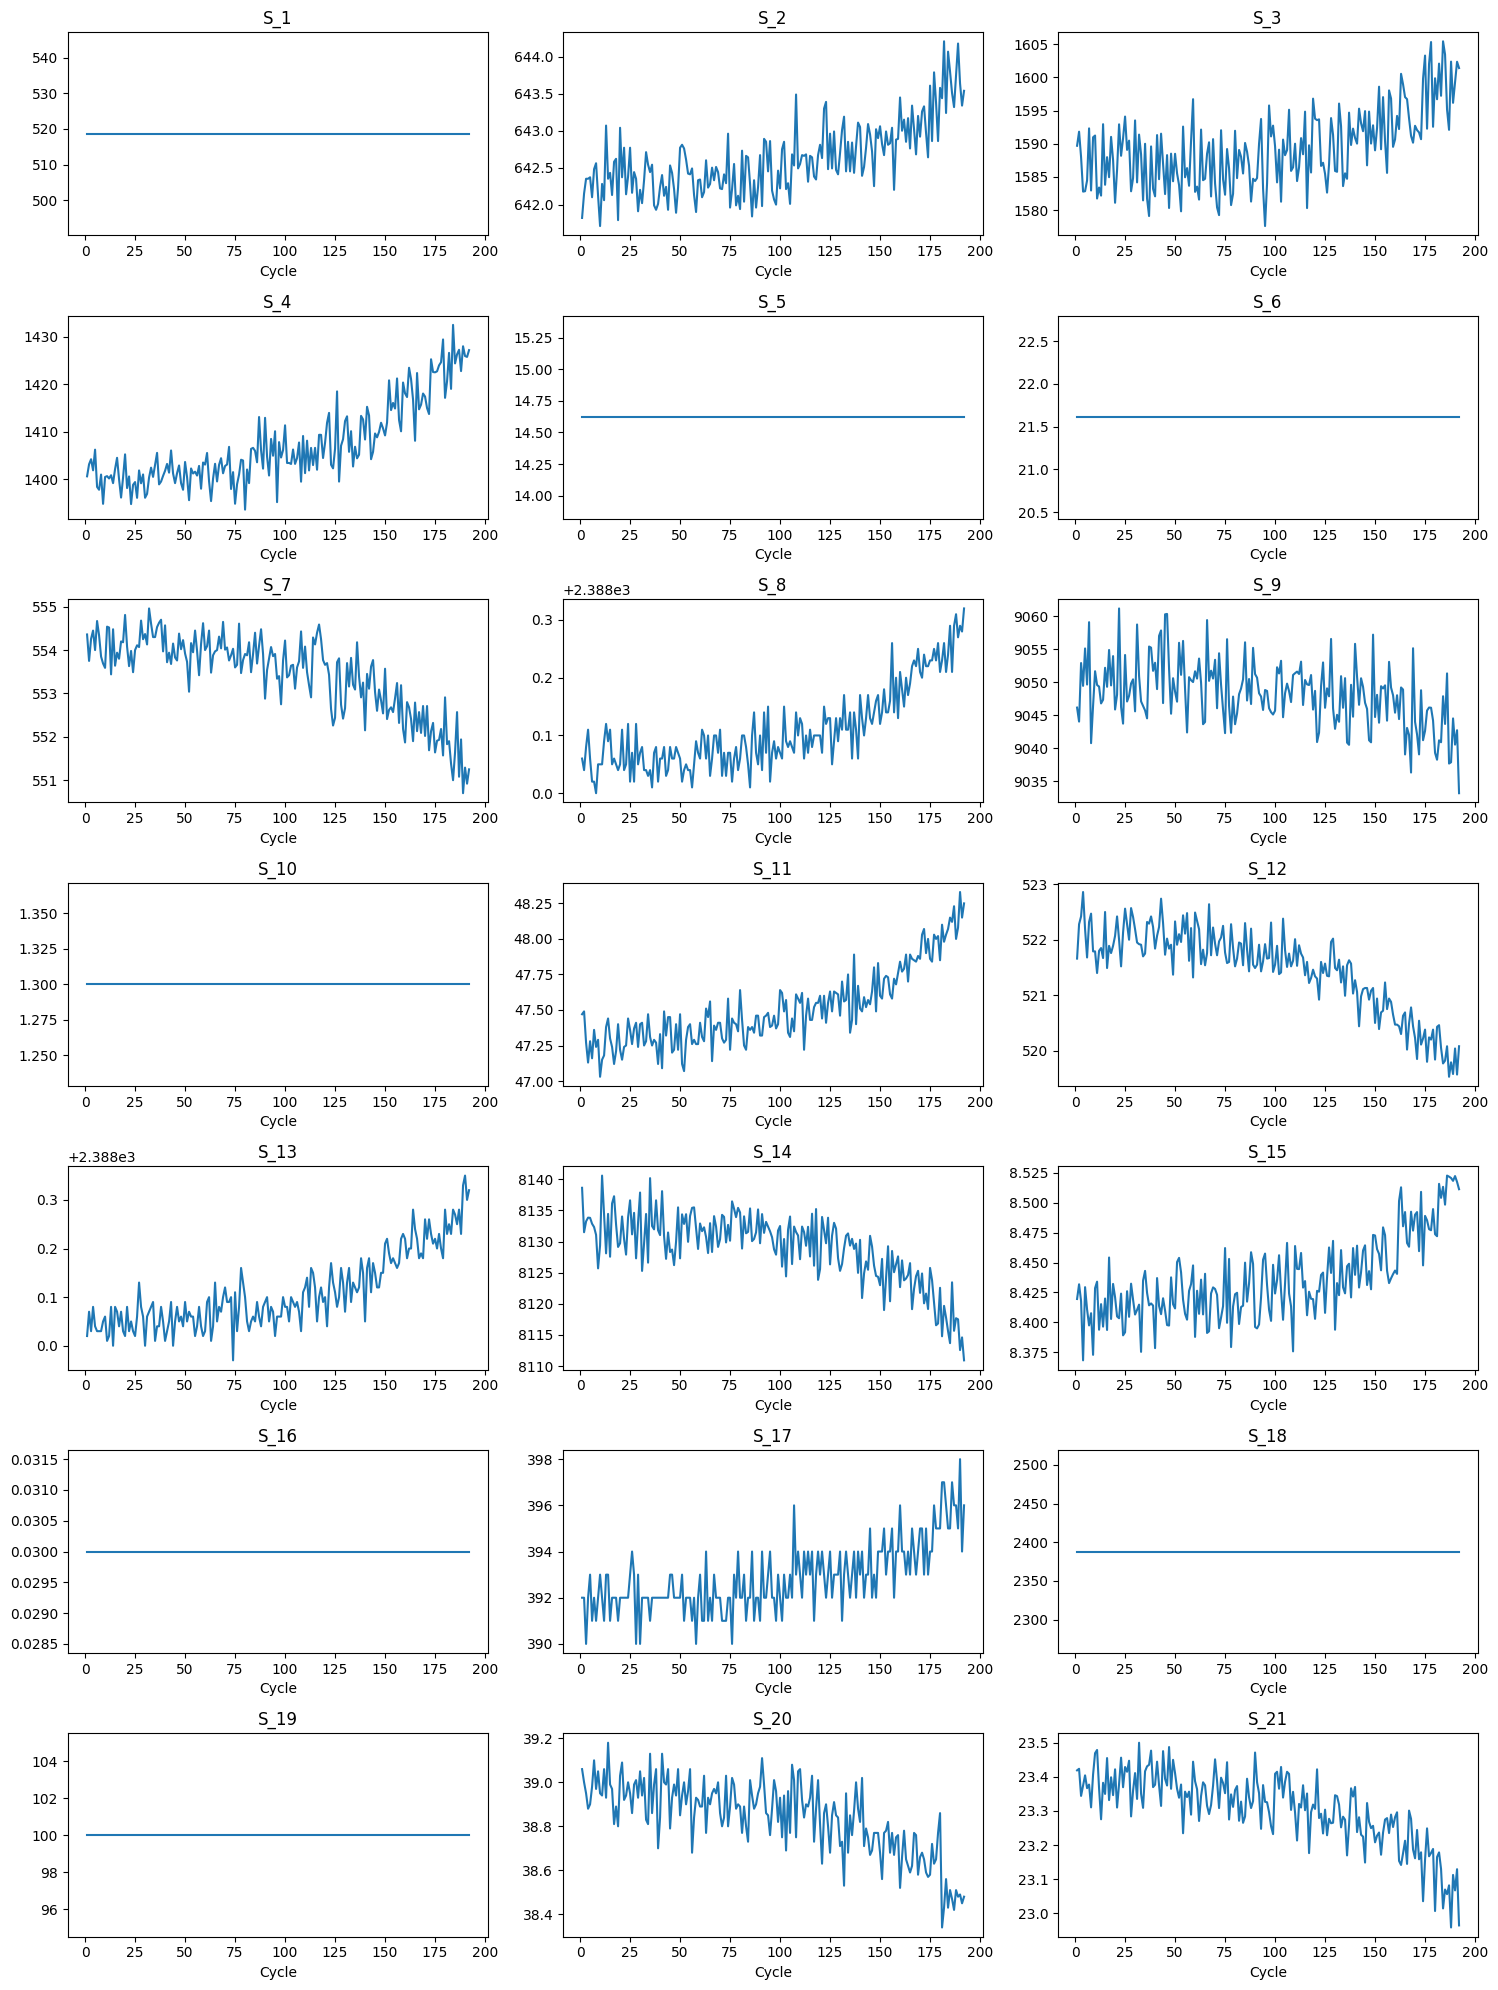

In [13]:
fig, axes = plt.subplots(7, 3, figsize=(15, 20))
axes = axes.flatten()

moteur1 = train_df[train_df['unit_number'] == 1]

for i, sensor in enumerate(sensor_names):
    axes[i].plot(moteur1['time_cycles'], moteur1[sensor])
    axes[i].set_title(sensor)
    axes[i].set_xlabel('Cycle')

plt.tight_layout()
plt.show()

On remarque par ces visualisations que tous les capteurs n'apportent pas une information les capteurs (S_19, S_18, S_16, S_10, S_8, S_9, S_6, S_5,et S_1), ils seront assez naturellement retiré des données à analyser. Par ailleurs une vérification statistique s'impose  

In [14]:
moteur1[sensor_names].std().sort_values()

,0
S_19,0.000000e+00
S_18,0.000000e+00
S_16,1.739259e-17
S_10,4.452502e-15
S_6,3.918202e-14
S_5,6.589703e-14
S_1,1.367809e-12
S_15,3.412461e-02
S_8,7.091352e-02
S_13,7.696013e-02


Le cacul de l'écart-type le confirme, les capteurs `S_19, S_18, S_16, S_10, S_6, S_5, S_1`, n'apportent aucune information d'autant plus que leurs écart-types sont presque égles à 0. <br>
Les capteurs `S_15 et S_2` bougent mais très peu, ils sont à surveiller mais ne sont pas les plus importants ici. <br>
Après une analyse rigoureuse des visualisations des capteurs restants pour déterminer lesquelles ont une tendance suffisamment claire pour avoir un impact sur la dégradation du moteur, Une question née, on doit désormais savoir si le rapport **signale/bruit** est plus informatif que la **tendance** sur l'impact du capte sur la dégradation du moteur

In [15]:
resultats = {}

for sensor in sensor_names:
    pente, _, _, _, _ = stats.linregress(moteur1['time_cycles'], moteur1[sensor])
    bruit = moteur1[sensor].std()
    if bruit > 0:
        ratio = abs(pente) / bruit
    else:
        ratio = 0
    resultats[sensor] = ratio

ratios = pd.Series(resultats).sort_values(ascending=False)
ratios

,0
S_11,0.015153
S_12,0.015091
S_13,0.014985
S_4,0.014830
S_8,0.014495
S_7,0.014370
S_21,0.013737
S_20,0.013134
S_15,0.013025
S_14,0.012833



* pente = à quel point la valeur change en moyenne à chaque cycle (la tendance)
* bruit = l'écart-type (la dispersion autour de cette tendance)
* ratio = plus il est élevé, plus le signal de dégradation est clair par rapport au bruit — donc plus le capteur est utile

Le ratio pente/bruit nous permet de voir à quel point le signal de dégradation d'un capteur est clair par rapport à son bruit, indépendamment de sa vitesse de dégradation.

L'analyse des résultats confirme ce qui a été observé visuellement : les capteurs qui n'apportent aucune information restent les mêmes (S_1, S_5, S_6, S_10, S_16, S_18, S_19 — ratio nul).

Pour les 14 capteurs restants, le ratio est assez homogène (entre 0.008 et 0.015) : aucun ne se distingue clairement des autres en termes de clarté du signal de dégradation. Ce calcul a été fait sur un seul moteur (unit 1) — il faudra vérifier si ce classement reste stable sur l'ensemble des 100 moteurs avant de tirer une conclusion définitive.

In [18]:
resultats_tous_moteurs = []

for unit in train_df['unit_number'].unique() :
  moteur = train_df[train_df['unit_number'] == unit]
  ratio_moteur = {}

  for sensor in sensor_names :
    pente, _, _, _, _= stats.linregress(moteur['time_cycles'], moteur[sensor])
    bruit = moteur[sensor].std()

    if bruit > 0 :
      ratio = abs(pente)/bruit

    else :
      ratio = 0

    ratio_moteur[sensor] = ratio

  resultats_tous_moteurs.append(ratio_moteur)

df_ratios = pd.DataFrame(resultats_tous_moteurs)
df_mean = df_ratios.mean().sort_values(ascending = False)

df_mean

,0
S_11,0.014186
S_12,0.013831
S_4,0.013685
S_7,0.013318
S_15,0.012674
S_21,0.012533
S_20,0.012491
S_13,0.012108
S_8,0.012048
S_14,0.011921


En conclusion, la sélection des 7 capteurs à exclure (capteurs plats) reste stable. Bien que la moyenne des ratios du capteur S_6 sur les 100 moteurs montre qu'il n'est plus totalement plat, son changement est minime, presque négligeable — on le garde donc dans la catégorie des capteurs exclus.

Les écarts entre les ratios des 14 autres capteurs restent assez faibles, on ne constate toujours aucune hiérarchie évidente parmi eux.

## **Etape 2** : Validation statistique avec le test de Mann-kendal

In [34]:
import pymannkendall as mk
data = {}

for sensor in sensor_names:
    resultat = mk.original_test(moteur1[sensor])
    data[sensor] = [resultat.trend, resultat.p]

trend_df = pd.DataFrame(data).T.rename(columns={0 : 'Trend',1 : 'P.value'})
trend_df.sort_values(ascending=False, by = 'P.value')

,Trend,P.value
S_1,no trend,1.0
S_5,no trend,1.0
S_6,no trend,1.0
S_19,no trend,1.0
S_18,no trend,1.0
S_10,no trend,1.0
S_16,no trend,1.0
S_9,decreasing,0.0
S_3,increasing,0.0
S_14,decreasing,0.0
